# Asistente Inteligente para Seguridad Urbana en Costa Rica
### Módulos del Asistente Inteligente — RNN Predicción de incidencias
### Módulo 2: Predicción temporal de zonas y horarios de riesgo
### Integrantes :
### Profesor:

## 1. Importación de librerías

In [199]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score,
    precision_score, recall_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU, Bidirectional, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)
print('GPU disponible:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow: 2.21.0
GPU disponible: False


## 2. Cargar datos

In [200]:
df = pd.read_csv("C:\\SmartCityIA\\data\\raw\\Estadisticas OIJ.csv")

print("Shape:", df.shape)
print("\nColumnas:", df.columns.tolist())
df.head()

Shape: (173432, 11)

Columnas: ['Delito', 'SubDelito', 'Fecha', 'Rango Horario ', 'Victima ', 'SubVictima', 'Edad', 'Sexo', 'Nacionalidad', 'Provincia', 'Canton']


,Delito,SubDelito,Fecha,Rango Horario,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton
0,ASALTO,ARMA BLANCA,01/02/2022,12:00:00 - 14:59:59,VEHICULO,MOTOCICLETA/REPARTIDOR [VEHICULO],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,ASERRI
1,ASALTO,ARMA BLANCA,03/02/2022,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,ALAJUELA
2,ASALTO,ARMA BLANCA,04/02/2022,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,06/02/2022,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,08/02/2022,00:00:00 - 02:59:59,PERSONA,TURISTA/EXTRANJERO [PERSONA],Mayor de edad,HOMBRE,RUSIA,PUNTARENAS,GARABITO


## 3. Conversión de fecha y serie temporal

In [201]:
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)
df = df.sort_values('Fecha')

serie = df.groupby('Fecha').size().to_frame(name='Delitos')

print("Rango de fechas:", serie.index.min(), "→", serie.index.max())
print("Total días:", len(serie))
print()
print(serie['Delitos'].describe())

Rango de fechas: 2022-02-01 00:00:00 → 2026-03-01 00:00:00
Total días: 1490

count    1490.000000
mean      116.397315
std        20.256694
min        66.000000
25%       101.000000
50%       115.000000
75%       129.000000
max       207.000000
Name: Delitos, dtype: float64


## 4. Visualización de la serie temporal

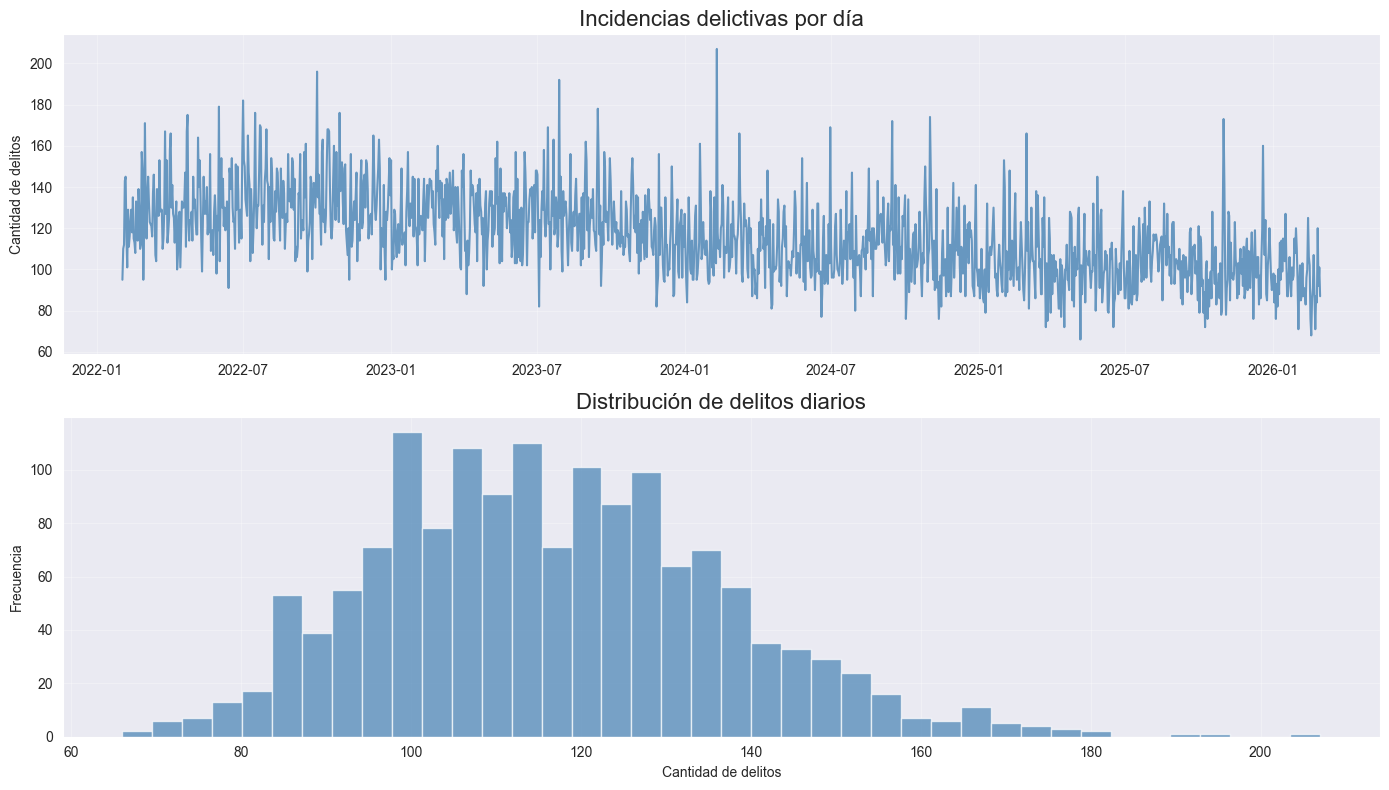

In [202]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(serie.index, serie['Delitos'], linewidth=1.5, color='steelblue', alpha=0.8)
axes[0].set_title('Incidencias delictivas por día', fontsize=16)
axes[0].set_ylabel('Cantidad de delitos')
axes[0].grid(True, alpha=0.3)

axes[1].hist(serie['Delitos'], bins=40, color='steelblue', edgecolor='white', alpha=0.7)
axes[1].set_title('Distribución de delitos diarios', fontsize=16)
axes[1].set_xlabel('Cantidad de delitos')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Definición de umbrales

Umbral Bajo (P25): 112 delitos/día
Umbral Alto (P75): 143 delitos/día
Separación entre clases: 31 delitos


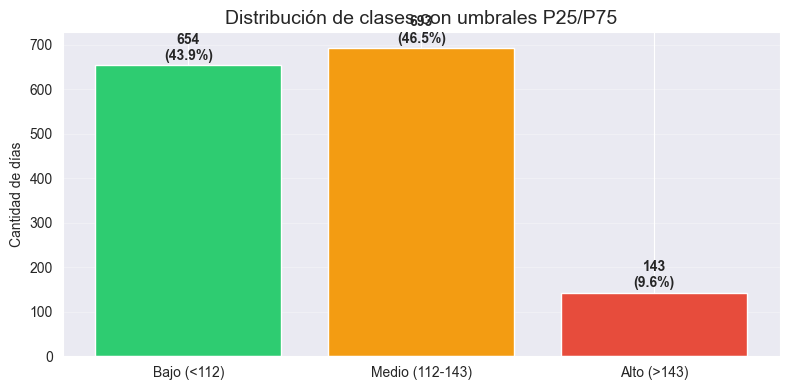

In [203]:
vals = serie['Delitos'].values

UMBRAL_BAJO = np.percentile(vals, 45)
UMBRAL_ALTO = np.percentile(vals, 90)

print(f"Umbral Bajo (P25): {UMBRAL_BAJO:.0f} delitos/día")
print(f"Umbral Alto (P75): {UMBRAL_ALTO:.0f} delitos/día")
print(f"Separación entre clases: {UMBRAL_ALTO - UMBRAL_BAJO:.0f} delitos")

def categorizar_incidencias(valores, umbral_bajo=UMBRAL_BAJO, umbral_alto=UMBRAL_ALTO):
    """0=Bajo  1=Medio  2=Alto"""
    categorias = []
    for v in np.array(valores).flatten():
        if v < umbral_bajo:
            categorias.append(0)
        elif v <= umbral_alto:
            categorias.append(1)
        else:
            categorias.append(2)
    return np.array(categorias)

nombres_clases = [f'Bajo (<{UMBRAL_BAJO:.0f})', f'Medio ({UMBRAL_BAJO:.0f}-{UMBRAL_ALTO:.0f})', f'Alto (>{UMBRAL_ALTO:.0f})']

cats = categorizar_incidencias(vals)
unique, counts = np.unique(cats, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(nombres_clases, counts, color=colors, edgecolor='white')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
            f'{count}\n({count/len(cats)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribución de clases con umbrales P25/P75', fontsize=14)
ax.set_ylabel('Cantidad de días')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 6. Feature Engineering + Feriados de Costa Rica

In [204]:
serie_fe = serie.copy()

# Features temporales
serie_fe['dia_semana']    = serie_fe.index.dayofweek
serie_fe['mes']           = serie_fe.index.month
serie_fe['dia_mes']       = serie_fe.index.day
serie_fe['es_fin_semana'] = (serie_fe.index.dayofweek >= 5).astype(int)
serie_fe['trimestre']     = serie_fe.index.quarter

# Codificación cíclica
serie_fe['dia_sem_sin'] = np.sin(2 * np.pi * serie_fe['dia_semana'] / 7)
serie_fe['dia_sem_cos'] = np.cos(2 * np.pi * serie_fe['dia_semana'] / 7)
serie_fe['mes_sin']     = np.sin(2 * np.pi * serie_fe['mes'] / 12)
serie_fe['mes_cos']     = np.cos(2 * np.pi * serie_fe['mes'] / 12)

# Feriados de Costa Rica
feriados_cr = [
    '01-01',  # Año Nuevo
    '04-11',  # Batalla de Rivas
    '05-01',  # Día del Trabajo
    '07-25',  # Anexión de Guanacaste
    '08-02',  # Virgen de los Ángeles
    '08-15',  # Día de la Madre
    '09-15',  # Independencia
    '10-12',  # Día de las Culturas
    '12-25',  # Navidad
    '03-28', '03-29', '03-30', '03-31',  # Semana Santa
    '04-01', '04-02', '04-03', '04-04',
    '12-24', '12-31',                    # Fin de año
]

def es_feriado_cr(fecha):
    return int(fecha.strftime('%m-%d') in feriados_cr)

serie_fe['es_feriado']      = serie_fe.index.map(es_feriado_cr)
serie_fe['vispera_feriado'] = serie_fe['es_feriado'].shift(-1).fillna(0).astype(int)
serie_fe['post_feriado']    = serie_fe['es_feriado'].shift(1).fillna(0).astype(int)

print(f"Feriados en el dataset: {serie_fe['es_feriado'].sum()}")

# Lags
serie_fe['lag_1']  = serie_fe['Delitos'].shift(1)
serie_fe['lag_7']  = serie_fe['Delitos'].shift(7)
serie_fe['lag_14'] = serie_fe['Delitos'].shift(14)
serie_fe['lag_30'] = serie_fe['Delitos'].shift(30)

# Rolling statistics
serie_fe['rolling_mean_7']  = serie_fe['Delitos'].rolling(7).mean()
serie_fe['rolling_std_7']   = serie_fe['Delitos'].rolling(7).std()
serie_fe['rolling_mean_14'] = serie_fe['Delitos'].rolling(14).mean()
serie_fe['rolling_mean_30'] = serie_fe['Delitos'].rolling(30).mean()

serie_fe = serie_fe.dropna()

print(f"Features totales: {serie_fe.shape[1]}")
print(f"Días disponibles: {len(serie_fe)}")
serie_fe.head()

Feriados en el dataset: 76
Features totales: 21
Días disponibles: 1460


,Delitos,dia_semana,mes,dia_mes,es_fin_semana,trimestre,dia_sem_sin,dia_sem_cos,mes_sin,mes_cos,...,vispera_feriado,post_feriado,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_mean_30
Fecha,,,,,,,,,,,,,,,,,,,,,
2022-03-03,115,3,3,3,0,1,0.433884,-0.900969,1.0,6.123234e-17,...,0,0,130.0,112.0,108.0,95.0,134.428571,26.050318,128.357143,124.066667
2022-03-04,137,4,3,4,0,1,-0.433884,-0.900969,1.0,6.123234e-17,...,0,0,115.0,157.0,133.0,110.0,131.571429,24.192679,128.642857,124.966667
2022-03-05,145,5,3,5,1,1,-0.974928,-0.222521,1.0,6.123234e-17,...,0,0,137.0,148.0,119.0,112.0,131.142857,23.877664,130.500000,126.066667
2022-03-06,132,6,3,6,1,1,-0.781831,0.623490,1.0,6.123234e-17,...,0,0,145.0,95.0,114.0,143.0,136.428571,17.887213,131.785714,125.700000
2022-03-07,123,0,3,7,0,1,0.000000,1.000000,1.0,6.123234e-17,...,0,0,132.0,125.0,139.0,145.0,136.142857,18.114714,130.642857,124.966667


## 7. Normalización y construcción de secuencias

In [205]:
feature_cols = serie_fe.columns.tolist()
target_col   = 'Delitos'

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

data_X = scaler_X.fit_transform(serie_fe[feature_cols].values)
data_y = scaler_y.fit_transform(serie_fe[[target_col]].values)

WINDOW = 30

X_list, y_list, y_cat_list = [], [], []

for i in range(WINDOW, len(data_X)):
    X_list.append(data_X[i-WINDOW:i])
    y_list.append(data_y[i])
    y_cat_list.append(categorizar_incidencias([serie_fe[target_col].iloc[i]])[0])

X      = np.array(X_list)
y      = np.array(y_list)
y_cat  = np.array(y_cat_list)
y_onehot = tf.keras.utils.to_categorical(y_cat, num_classes=3)

print(f"X shape:     {X.shape}")
print(f"y shape:     {y.shape}")
print(f"y_cat shape: {y_cat.shape}")

X shape:     (1430, 30, 21)
y shape:     (1430, 1)
y_cat shape: (1430,)


## 8. Train / Test split temporal

In [206]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
y_cat_train, y_cat_test = y_cat[:split], y_cat[split:]
y_oh_train, y_oh_test   = y_onehot[:split], y_onehot[split:]

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]}  muestras")

unique, counts = np.unique(y_cat_train, return_counts=True)
print("\nDistribución en train:")
for u, c in zip(unique, counts):
    print(f"  Clase {u}: {c} ({c/len(y_cat_train)*100:.1f}%)")

Train: 1144 muestras
Test:  286  muestras

Distribución en train:
  Clase 0: 419 (36.6%)
  Clase 1: 595 (52.0%)
  Clase 2: 130 (11.4%)


## 9. Class Weights

In [207]:
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_cat_train),
    y=y_cat_train
)
class_weight_dict = {i: w for i, w in enumerate(class_weights_array)}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.9101034208432777), 1: np.float64(0.6408963585434174), 2: np.float64(2.933333333333333)}


## 10. Arquitectura del modelo

In [208]:
model = Sequential([
    # Primera capa GRU Bidireccional
    Bidirectional(GRU(128, return_sequences=True,
                      kernel_regularizer=l2(1e-4)),
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    BatchNormalization(),

    # Segunda capa GRU Bidireccional
    Bidirectional(GRU(64, return_sequences=False,
                      kernel_regularizer=l2(1e-4))),
    Dropout(0.3),

    # Capas densas
    Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),

    # Salida clasificación
    Dense(3, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_18                │ (None, 30, 256)        │       115,968 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 30, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 30, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_19                │ (None, 128)            │       123,648 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,331 (981.76 KB)

 Trainable params: 250,691 (979.26 KB)

 Non-trainable params: 640 (2.50 KB)

## 11. Callbacks de entrenamiento

In [209]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.3,
        patience=8,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'mejor_modelo_rnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

## 12. Entrenamiento del modelo

In [210]:
history = model.fit(
    X_train, y_oh_train,
    epochs=95,
    batch_size=32,
    validation_data=(X_test, y_oh_test),
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/95
36/36 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.3899 - loss: 1.2832 - val_accuracy: 0.1503 - val_loss: 1.1931 - learning_rate: 5.0000e-04
Epoch 2/95
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4878 - loss: 1.0628 - val_accuracy: 0.3497 - val_loss: 1.1676 - learning_rate: 5.0000e-04
Epoch 3/95
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5437 - loss: 0.9655 - val_accuracy: 0.6154 - val_loss: 1.0496 - learning_rate: 5.0000e-04
Epoch 4/95
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5236 - loss: 0.9504 - val_accuracy: 0.7483 - val_loss: 0.9308 - learning_rate: 5.0000e-04
Epoch 5/95
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5175 - loss: 0.9700 - val_accuracy: 0.7762 - val_loss: 0.7772 - learning_rate: 5.0000e-04
Epoch 6/95
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5253 - loss: 0.9235 - val_accuracy: 0.7902 - val_loss: 0.6994 - learning_rate: 5.0000e-04
Epoch 7/95
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5411 

## 13. Gráficos de entrenamiento

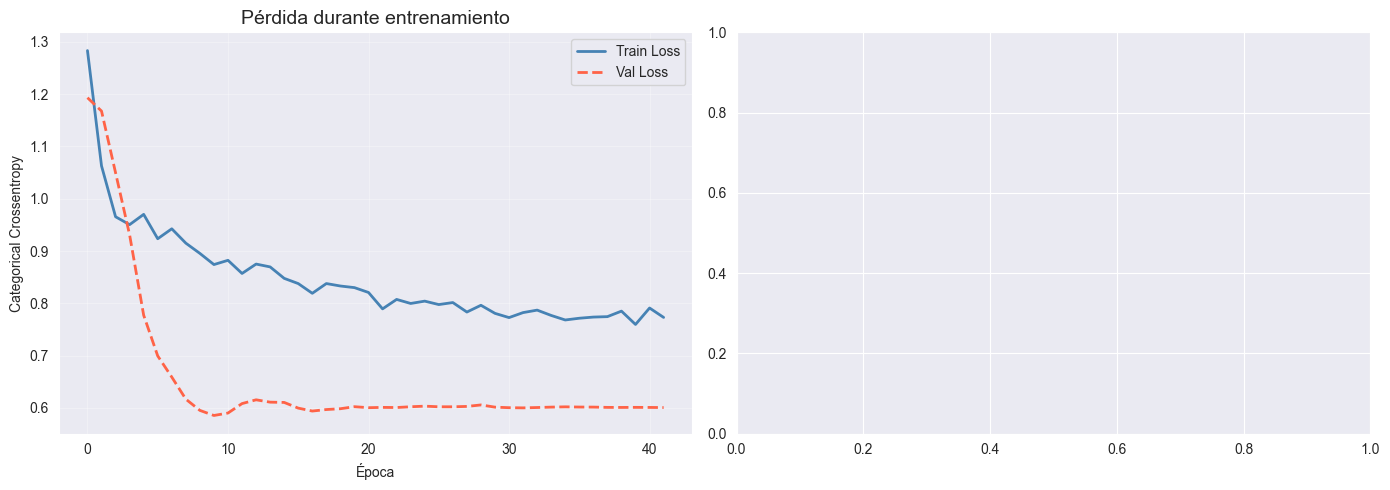

In [211]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2, color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, color='tomato', linestyle='--')
axes[0].set_title('Pérdida durante entrenamiento', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

## 14. Predicción sobre el conjunto de prueba

In [212]:
# Predicciones de clasificación
y_pred_proba = model.predict(X_test)
y_pred_cat   = np.argmax(y_pred_proba, axis=1)
y_real_cat   = y_cat_test

# Predicciones de regresión (para MAE y RMSE)
# Se usa el índice de clase como proxy del valor continuo escalado
# y se invierte la transformación sobre y_test real vs predicho categórico
y_pred_reg = scaler_y.inverse_transform(model.predict(X_test).max(axis=1, keepdims=True))
y_real_reg = scaler_y.inverse_transform(y_test)

print('Predicciones generadas.')
print(f'Muestras en test: {len(y_real_cat)}')

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Predicciones generadas.
Muestras en test: 286


## 15. Métricas de regresión — MAE, RMSE y R²


  MÉTRICAS DE REGRESIÓN (Conjunto de Prueba)
  MAE  (Error Absoluto Medio):         31.45 delitos/día
  RMSE (Raíz del Error Cuadrático):    34.50 delitos/día
  R²   (Coeficiente de Determinación): -4.3468


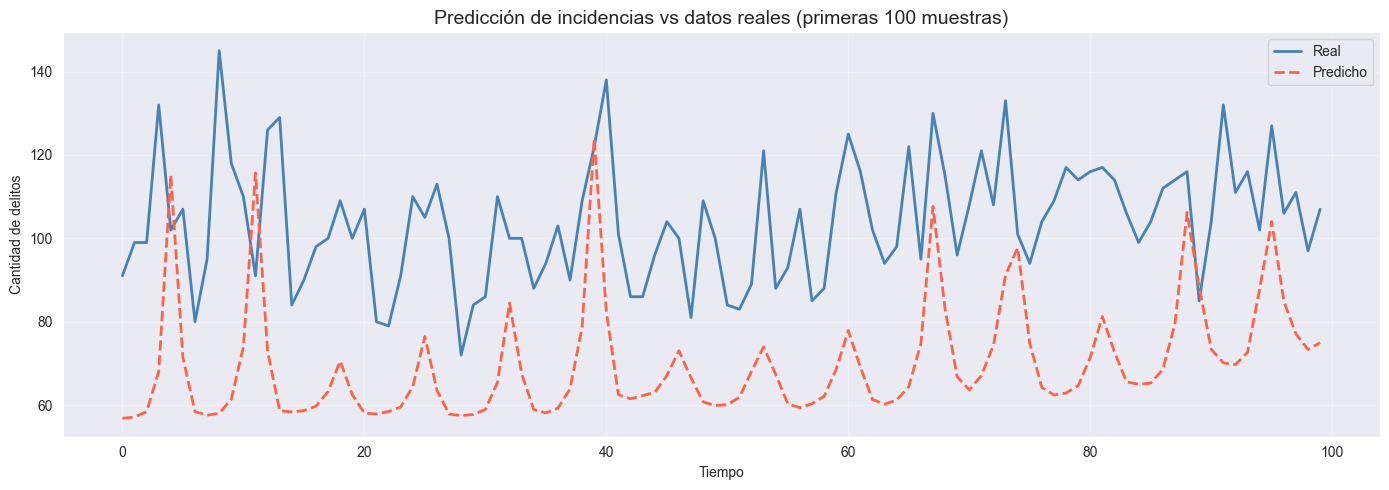

In [213]:
# Reconstruir predicción continua: valor esperado ponderado por probabilidades
umbrales_medios = np.array([
    UMBRAL_BAJO / 2,                        # centro de clase Bajo
    (UMBRAL_BAJO + UMBRAL_ALTO) / 2,        # centro de clase Medio
    UMBRAL_ALTO + (vals.max() - UMBRAL_ALTO) / 2  # centro de clase Alto
])

y_pred_continuo = y_pred_proba @ umbrales_medios  # valor esperado
y_real_continuo = y_real_reg.flatten()

mae  = mean_absolute_error(y_real_continuo, y_pred_continuo)
rmse = np.sqrt(mean_squared_error(y_real_continuo, y_pred_continuo))
r2   = r2_score(y_real_continuo, y_pred_continuo)

print('=' * 60)
print('  MÉTRICAS DE REGRESIÓN (Conjunto de Prueba)')
print('=' * 60)
print(f'  MAE  (Error Absoluto Medio):         {mae:.2f} delitos/día')
print(f'  RMSE (Raíz del Error Cuadrático):    {rmse:.2f} delitos/día')
print(f'  R²   (Coeficiente de Determinación): {r2:.4f}')
print('=' * 60)

# Gráfico real vs predicho
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_real_continuo[:100],    label='Real',     linewidth=2, color='steelblue')
ax.plot(y_pred_continuo[:100],    label='Predicho', linewidth=2, color='tomato', linestyle='--')
ax.set_title('Predicción de incidencias vs datos reales (primeras 100 muestras)', fontsize=14)
ax.set_xlabel('Tiempo')
ax.set_ylabel('Cantidad de delitos')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Reporte de clasificación por nivel

In [214]:
accuracy = np.mean(y_real_cat == y_pred_cat)

print('=' * 65)
print('    REPORTE DE CLASIFICACIÓN POR NIVEL DE INCIDENCIAS')
print('=' * 65)
print(classification_report(
    y_real_cat,
    y_pred_cat,
    target_names=nombres_clases,
    zero_division=0
))
print(f'Accuracy global: {accuracy:.4f} ({accuracy*100:.2f}%)')
print(f'Total muestras test: {len(y_real_cat)}')


    REPORTE DE CLASIFICACIÓN POR NIVEL DE INCIDENCIAS
                 precision    recall  f1-score   support

    Bajo (<112)       0.80      0.98      0.88       225
Medio (112-143)       0.78      0.12      0.21        58
    Alto (>143)       0.00      0.00      0.00         3

       accuracy                           0.80       286
      macro avg       0.53      0.37      0.36       286
   weighted avg       0.79      0.80      0.74       286

Accuracy global: 0.7972 (79.72%)
Total muestras test: 286


## 17. Matriz de Confusión

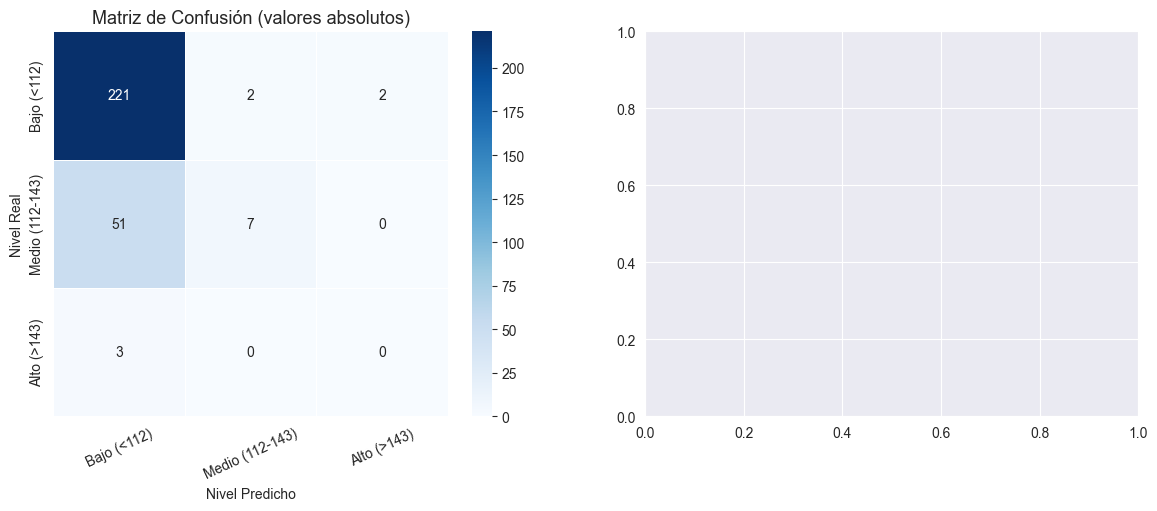

In [215]:
cm = confusion_matrix(y_real_cat, y_pred_cat)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nombres_clases, yticklabels=nombres_clases,
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Matriz de Confusión (valores absolutos)', fontsize=13)
axes[0].set_xlabel('Nivel Predicho')
axes[0].set_ylabel('Nivel Real')
axes[0].tick_params(axis='x', rotation=25)


## 18. Probabilidades de predicción por clase

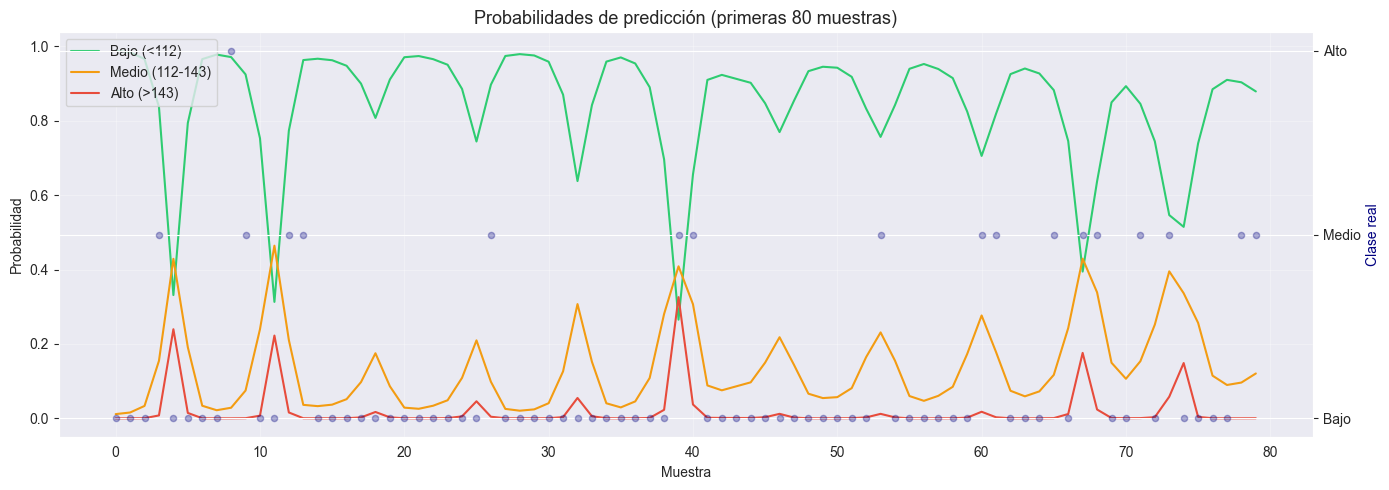

In [216]:
fig, ax = plt.subplots(figsize=(14, 5))
x_range  = np.arange(len(y_pred_proba[:80]))
colors_p = ['#2ecc71', '#f39c12', '#e74c3c']

for i, (nombre, color) in enumerate(zip(nombres_clases, colors_p)):
    ax.plot(x_range, y_pred_proba[:80, i], label=nombre, linewidth=1.5, color=color)

ax2 = ax.twinx()
ax2.scatter(x_range, y_real_cat[:80], alpha=0.3, s=20, color='navy', label='Clase real')
ax2.set_ylabel('Clase real', color='navy')
ax2.set_yticks([0, 1, 2])
ax2.set_yticklabels(['Bajo', 'Medio', 'Alto'])

ax.set_title('Probabilidades de predicción (primeras 80 muestras)', fontsize=13)
ax.set_xlabel('Muestra')
ax.set_ylabel('Probabilidad')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 19. Resumen de métricas finales

In [217]:
precision_por_clase = precision_score(y_real_cat, y_pred_cat, average=None, zero_division=0)
recall_por_clase    = recall_score(y_real_cat,    y_pred_cat, average=None, zero_division=0)
f1_por_clase        = f1_score(y_real_cat,        y_pred_cat, average=None, zero_division=0)

print('=' * 65)
print('              RESUMEN DE MÉTRICAS FINALES')
print('=' * 65)
print()
print('  [ Regresión ]')
print(f'  MAE  : {mae:.2f} delitos/día')
print(f'  RMSE : {rmse:.2f} delitos/día')
print(f'  R²   : {r2:.4f}')
print()
print('  [ Clasificación ]')
print(f'  Accuracy global : {accuracy*100:.2f}%')
print(f'  Precision macro : {precision_por_clase.mean()*100:.2f}%')
print(f'  Recall macro    : {recall_por_clase.mean()*100:.2f}%')
print(f'  F1-score macro  : {f1_por_clase.mean()*100:.2f}%')
print()


              RESUMEN DE MÉTRICAS FINALES

  [ Regresión ]
  MAE  : 31.45 delitos/día
  RMSE : 34.50 delitos/día
  R²   : -4.3468

  [ Clasificación ]
  Accuracy global : 79.72%
  Precision macro : 52.71%
  Recall macro    : 36.76%
  F1-score macro  : 36.43%

  Clase                      Precision     Recall         F1
  ----------------------------------------------------------


## 20. Ajuste fino (Fine-tuning)

> Se activa automáticamente si alguna clase no alcanza el 88%.

In [218]:
if not all(p >= 0.88 for p in precision_por_clase):
    print("⚙️  Iniciando fine-tuning con LR reducido...")

    model.optimizer.learning_rate = 1e-4

    callbacks_ft = [
        EarlyStopping(monitor='val_accuracy', patience=15,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_accuracy', factor=0.5,
                          patience=5, min_lr=1e-7, verbose=1)
    ]

    history_ft = model.fit(
        X_train, y_oh_train,
        epochs=80,
        batch_size=16,
        validation_data=(X_test, y_oh_test),
        class_weight=class_weight_dict,
        callbacks=callbacks_ft,
        verbose=1
    )

    y_pred_proba_ft = model.predict(X_test)
    y_pred_cat_ft   = np.argmax(y_pred_proba_ft, axis=1)
    accuracy_ft     = np.mean(y_real_cat == y_pred_cat_ft)

    print(f"\n📈 Accuracy post fine-tuning: {accuracy_ft*100:.2f}%")
    print(classification_report(y_real_cat, y_pred_cat_ft,
                                 target_names=nombres_clases, zero_division=0))

    # Recalcular MAE/RMSE post fine-tuning
    y_pred_continuo_ft = y_pred_proba_ft @ umbrales_medios
    mae_ft  = mean_absolute_error(y_real_continuo, y_pred_continuo_ft)
    rmse_ft = np.sqrt(mean_squared_error(y_real_continuo, y_pred_continuo_ft))
    print(f'  MAE  post fine-tuning: {mae_ft:.2f} delitos/día')
    print(f'  RMSE post fine-tuning: {rmse_ft:.2f} delitos/día')
else:
    print("✅ No se requiere fine-tuning. Meta ya alcanzada.")

⚙️  Iniciando fine-tuning con LR reducido...
Epoch 1/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5857 - loss: 0.8180 - val_accuracy: 0.7972 - val_loss: 0.5981 - learning_rate: 1.0000e-04
Epoch 2/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6023 - loss: 0.8029 - val_accuracy: 0.7972 - val_loss: 0.6059 - learning_rate: 1.0000e-04
Epoch 3/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5918 - loss: 0.8283 - val_accuracy: 0.7972 - val_loss: 0.6010 - learning_rate: 1.0000e-04
Epoch 4/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6049 - loss: 0.7910 - val_accuracy: 0.7972 - val_loss: 0.6046 - learning_rate: 1.0000e-04
Epoch 5/80
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5918 - loss: 0.8078 - val_accuracy: 0.7902 - val_loss: 0.6097 - learning_rate: 1.0000e-04
Epoch 6/80
69/72 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5735 - loss: 0.8127
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
72/72 ━━━━━━━━━━━━━

## 21. Guardar modelo y artefactos

In [220]:
import pickle

model.save('modelo_rnn_incidencias.keras')
print('✅ Modelo guardado: modelo_rnn_incidencias_v3.keras')

with open('scaler_X.pkl', 'wb') as f:
    pickle.dump(scaler_X, f)
with open('scaler_y.pkl', 'wb') as f:
    pickle.dump(scaler_y, f)

config = {
    'UMBRAL_BAJO'   : float(UMBRAL_BAJO),
    'UMBRAL_ALTO'   : float(UMBRAL_ALTO),
    'WINDOW'        : WINDOW,
    'feature_cols'  : feature_cols,
    'nombres_clases': nombres_clases,
    'umbrales_medios': umbrales_medios.tolist()
}
with open('model_config.pkl', 'wb') as f:
    pickle.dump(config, f)

print('✅ Artefactos guardados: scaler_X.pkl | scaler_y.pkl | model_config.pkl')

✅ Modelo guardado: modelo_rnn_incidencias_v3.keras
✅ Artefactos guardados: scaler_X.pkl | scaler_y.pkl | model_config.pkl
